In [538]:
import time
import json
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import Normalize
from PIL import Image

from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_cond,show_crossbar,DataLoader

In [539]:
chip=CHIP(PS(host="192.168.1.10", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0)
chip.adc.set_gap(adc_cs_gap=100,adc_first_gap=20,adc_last_gap=10)
chip.add_compiler("./code/")

Connected to 192.168.1.10:7
local ip: 192.168.1.15 local port: 64876
正在编译文件:  ./code/read_point3.txt
正在编译文件:  ./code/read_point3_col.txt
正在编译文件:  ./code/row_read_point3.txt
正在编译文件:  ./code/set_reset.txt
正在编译文件:  ./code/write_verify.txt
正在编译文件:  ./code/汇编测试代码.txt
正在编译文件:  ./code/读任意大小的块-汇编代码示例.txt
正在编译文件:  ./code/读单点测试.txt


In [ ]:
pos = (0,256,0,256)
chip.write_point3(*pos,write_voltage=5,tg=5,pulse_width=1e-6,set_device=True)
# voltage = chip.read_point3(*pos,read_voltage=5,tg=3,gain=1,from_row=False,out_type=0)

接收超时! 期望大小4,实际大小0,结果b''


0.012131107516708884
4.116181495866229
[[-0.94988804  0.31662935 -0.94988804 ... -1.26651738  0.31662935
  -2.21640542]
 [-1.26651738  0.31662935 -1.26651738 ... -0.63325869  1.58314673
  -0.31662935]
 [-0.31662935 -0.63325869  0.         ...  0.31662935  0.94988804
   0.63325869]
 ...
 [-0.94988804 -0.94988804  1.26651738 ... -0.94988804 -1.58314673
  -0.63325869]
 [ 1.26651738 -1.26651738  0.31662935 ... -0.31662935  0.
   0.        ]
 [ 2.84966411  0.94988804  1.58314673 ...  0.31662935 -1.58314673
   1.58314673]]


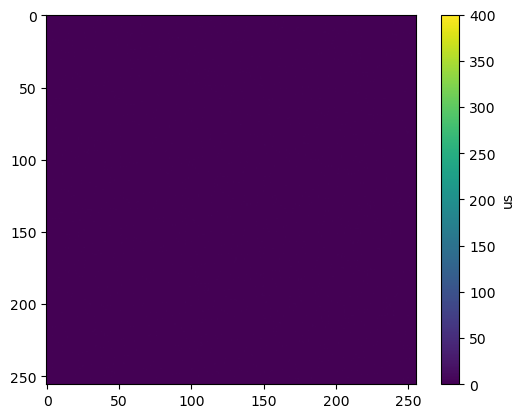

In [540]:
pos = (0,256,0,256)
voltage_base = chip.read_point3(*pos,read_voltage=0,tg=5,gain=1,from_row=True,out_type=0)
voltage = chip.read_point3(*pos,read_voltage=0.1,tg=5,gain=1,from_row=True,out_type=0)
print(np.max(voltage))
cond = chip.voltage_to_cond(voltage=voltage-voltage_base)
print(np.max(cond))
print(cond)
# print(cond[0])
# print(cond.shape)
plot_cond(cond,vmax=400)

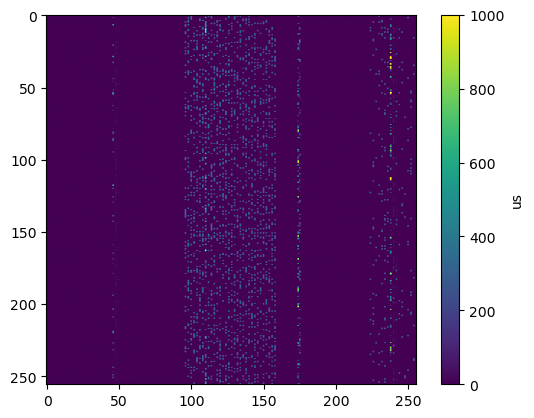

In [436]:
plot_cond(cond,vmax=1000)

0.13889736625263222


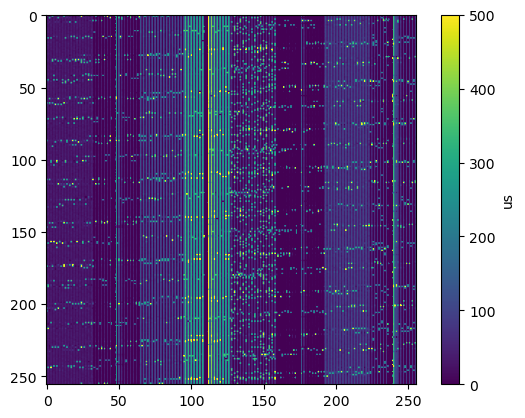

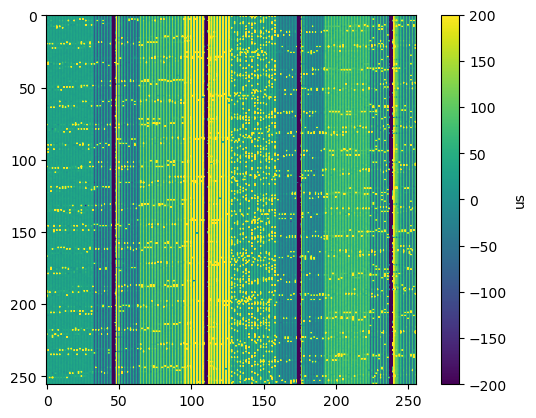

In [271]:
print(np.max(voltage))
cond = chip.voltage_to_cond(voltage=voltage)
# print(cond)

plot_cond(cond,vmax=500)
cond = chip.voltage_to_cond(voltage=voltage_base)
# print(cond)

plot_cond(cond,vmin=-200,vmax=200)

In [199]:
cond = cond[cond<400]
print(len(cond))
# plot_cond(cond)

489


In [ ]:
dl = DataLoader()
data = dl.load_csv("./data/HNN_W_matrix_origin.csv")
print(data.shape)
print(np.max(data),np.min(data))
plot_cond(data,vmin=-0.17,vmax=0.17)